# DEG20 Downstream Experiment

多条件版 scPRAM-style DEG20 downstream 实验。这个 notebook 直接消费现有 full-gene `pkl`，不重新训练模型。

核心定义：
- 真实 DEG20：直接使用 `DE_idx / DE_name`，即我们当前 TriShift 口径的 `top20_degs_non_dropout`。
- 预测 DEG20：从 `Pred_full / Ctrl_full` 生成。多行预测优先走 Scanpy 排名；单行预测自动退化为 effect-size 排名。
- 主指标：`common_degs_at_20`、`jaccard_at_20`、`precision_at_20`、`recall_at_20`，以及限定在 truth DEG20 上的 `scpram_r2_degs_mean_mean / scpram_r2_degs_var_mean / scpram_wasserstein_degs_sum`。

默认推荐：
- `truth_deg_mode = "payload"`
- `truth_deg_mode = "scanpy"` ?? `Truth_full vs Ctrl_full` ? Scanpy ?????? `DEG20`
- `truth_deg_mode = "effect_size"` ?? `|mu_truth - mu_ctrl| + top20` ???? `DEG20`
- `truth_deg_mode = "effect_size_non_dropout"` 可按 `|mu_truth - mu_ctrl| + non-dropout + 去掉 perturb gene + top20` 生成真实 `DEG20`
- `truth_deg_mode = "ttest_non_dropout"` 可按 `Truth_full vs Ctrl_full` 的 `t-test + non-dropout + 去掉 perturb gene + top20` 生成真实 `DEG20`
- `pred_deg_mode = "adaptive"`
- `pred_deg_mode = "ttest_non_dropout"` 可按和真实 `DEG20` 更接近的口径生成预测 `DEG20`
- `pred_deg_mode = "effect_size_non_dropout"` 可按 `|mu_pred - mu_ctrl| + non-dropout + 去掉 perturb gene + top20` 生成预测 `DEG20`
- `enrichment_mode = "export_only"`
- `n_degs = 20` ???? top20????????helper ???? top-k ?? truth / pred DEG ??
- `variant_tag = "nearest"` 仅在 `model_name="trishift"` 且目标产物是 `trishift_*_nearest.pkl` 时需要设置

- ? `payload` ?????? `artifacts/cache/degs/` ?????? truth DEG pkl ???????? `<dataset>_degs.pkl`


In [118]:
from __future__ import annotations

import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
if not (repo_root / "scripts").exists() and (repo_root.parent / "scripts").exists():
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

import scripts.trishift.analysis.deg20_experiment as deg20_experiment
importlib.reload(deg20_experiment)

run_deg20_experiment = deg20_experiment.run_deg20_experiment
load_condition_payload = deg20_experiment.load_condition_payload
summarize_condition_payload = deg20_experiment.summarize_condition_payload
build_mean_var_scatter = deg20_experiment.build_mean_var_scatter

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
repo_root


WindowsPath('e:/CODE/trishift')

## Parameters

设置一个模型、一个数据集，以及要分析的 split。


In [ ]:
dataset = "adamson"
model_name = "trishift"  # trishift | gears | genepert | scouter
split_ids = [1]
result_dir = None  # 可手动覆盖结果目录
out_root = None  # 可手动覆盖 notebook 输出目录
variant_tag = ""  # trishift ??: nearest / random / None
focus_conditions = []  # 例如 ["ATP5B+ctrl", "BHLHE40+ctrl"]
truth_deg_mode = "effect_size_non_dropout"  # payload | scanpy | effect_size | effect_size_non_dropout | ttest_non_dropout
pred_deg_mode =  "effect_size_non_dropout"  # adaptive | scanpy | effect_size | effect_size_non_dropout | ttest_non_dropout
n_degs = 100  # ?? truth/pred DEG ? top-k??? 20
enrichment_mode = "export_only"  # export_only | run_if_available | disabled
enrichment_library = "Reactome_2022"
remove_perturbed_genes = True

run_kwargs = dict(
    dataset=dataset,
    model_name=model_name,
    split_ids=split_ids,
    result_dir=result_dir,
    out_root=out_root,
    variant_tag=variant_tag,
    focus_conditions=focus_conditions or None,
    truth_deg_mode=truth_deg_mode,
    pred_deg_mode=pred_deg_mode,
    n_degs=n_degs,
    enrichment_mode=enrichment_mode,
    enrichment_library=enrichment_library,
    remove_perturbed_genes=remove_perturbed_genes,
)
run_kwargs


{'dataset': 'adamson',
 'model_name': 'trishift',
 'split_ids': [1],
 'result_dir': None,
 'out_root': None,
 'variant_tag': '',
 'focus_conditions': None,
 'truth_deg_mode': 'ttest_non_dropout',
 'pred_deg_mode': 'effect_size_non_dropout',
 'n_degs': 100,
 'enrichment_mode': 'export_only',
 'enrichment_library': 'Reactome_2022',
 'remove_perturbed_genes': True}

In [120]:
result = run_deg20_experiment(**run_kwargs)
print(f"out_dir: {result.out_dir}")
display(result.dataset_summary_df)
display(result.split_summary_df)
display(result.per_condition_df.head(20))


out_dir: E:\CODE\trishift\artifacts\results\adamson\deg20_downstream_20260315_215005


,model_name,dataset,deg_top_k,n_splits,common_degs_at_20_mean,common_degs_at_20_median,jaccard_at_20_mean,jaccard_at_20_median,precision_at_20_mean,precision_at_20_median,recall_at_20_mean,recall_at_20_median,truth_deg_count_mean,truth_deg_count_median,pred_deg_count_mean,pred_deg_count_median,scpram_r2_degs_mean_mean_mean,scpram_r2_degs_mean_mean_median,scpram_r2_degs_var_mean_mean,scpram_r2_degs_var_mean_median,scpram_wasserstein_degs_sum_mean,scpram_wasserstein_degs_sum_median
0,trishift,adamson,100,1,55.117647,57.0,0.386841,0.398601,0.551176,0.57,0.551176,0.57,100.0,100.0,100.0,100.0,0.966375,0.985507,0.633178,0.67938,22.495983,17.040716


,model_name,dataset,split_id,deg_top_k,n_conditions,n_scanpy_rank,n_effect_size_fallback,common_degs_at_20_mean,common_degs_at_20_median,jaccard_at_20_mean,jaccard_at_20_median,precision_at_20_mean,precision_at_20_median,recall_at_20_mean,recall_at_20_median,truth_deg_count_mean,truth_deg_count_median,pred_deg_count_mean,pred_deg_count_median,scpram_r2_degs_mean_mean_mean,scpram_r2_degs_mean_mean_median,scpram_r2_degs_var_mean_mean,scpram_r2_degs_var_mean_median,scpram_wasserstein_degs_sum_mean,scpram_wasserstein_degs_sum_median
0,trishift,adamson,1,100,17,0,0,55.117647,57.0,0.386841,0.398601,0.551176,0.57,0.551176,0.57,100.0,100.0,100.0,100.0,0.966375,0.985507,0.633178,0.67938,22.495983,17.040716


,model_name,dataset,split_id,condition,focus_key,pkl_path,deg_top_k,truth_deg_mode_used,pred_deg_mode_used,common_degs_at_20,jaccard_at_20,precision_at_20,recall_at_20,truth_deg_count,pred_deg_count,scpram_r2_degs_mean_mean,scpram_r2_degs_var_mean,scpram_wasserstein_degs_sum
0,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,66,0.492537,0.66,0.66,100,100,0.993611,0.723844,13.515372
1,trishift,adamson,1,BHLHE40+ctrl,1:BHLHE40+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,24,0.136364,0.24,0.24,100,100,0.908418,0.558763,51.192151
2,trishift,adamson,1,CARS+ctrl,1:CARS+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,60,0.428571,0.60,0.60,100,100,0.817369,0.307958,48.645445
3,trishift,adamson,1,CCND3+ctrl,1:CCND3+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,46,0.298701,0.46,0.46,100,100,0.959368,0.736190,25.842792
4,trishift,adamson,1,COPB1+ctrl,1:COPB1+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,61,0.438849,0.61,0.61,100,100,0.977511,0.433095,20.477210
5,trishift,adamson,1,DERL2+ctrl,1:DERL2+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,57,0.398601,0.57,0.57,100,100,0.992902,0.786751,16.632420
6,trishift,adamson,1,HARS+ctrl,1:HARS+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,62,0.449275,0.62,0.62,100,100,0.920370,0.570097,32.751987
7,trishift,adamson,1,HYOU1+ctrl,1:HYOU1+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,47,0.307190,0.47,0.47,100,100,0.987569,0.644328,16.389261
8,trishift,adamson,1,MANF+ctrl,1:MANF+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,67,0.503759,0.67,0.67,100,100,0.995176,0.679380,14.120544
9,trishift,adamson,1,MRPL39+ctrl,1:MRPL39+ctrl,E:\CODE\trishift\artifacts\results\adamson\tri...,100,ttest_non_dropout,effect_size_non_dropout,54,0.369863,0.54,0.54,100,100,0.990558,0.565595,14.259628


## Metric Distributions

这里先看每个 condition 的 overlap / regression / Wasserstein 指标分布。


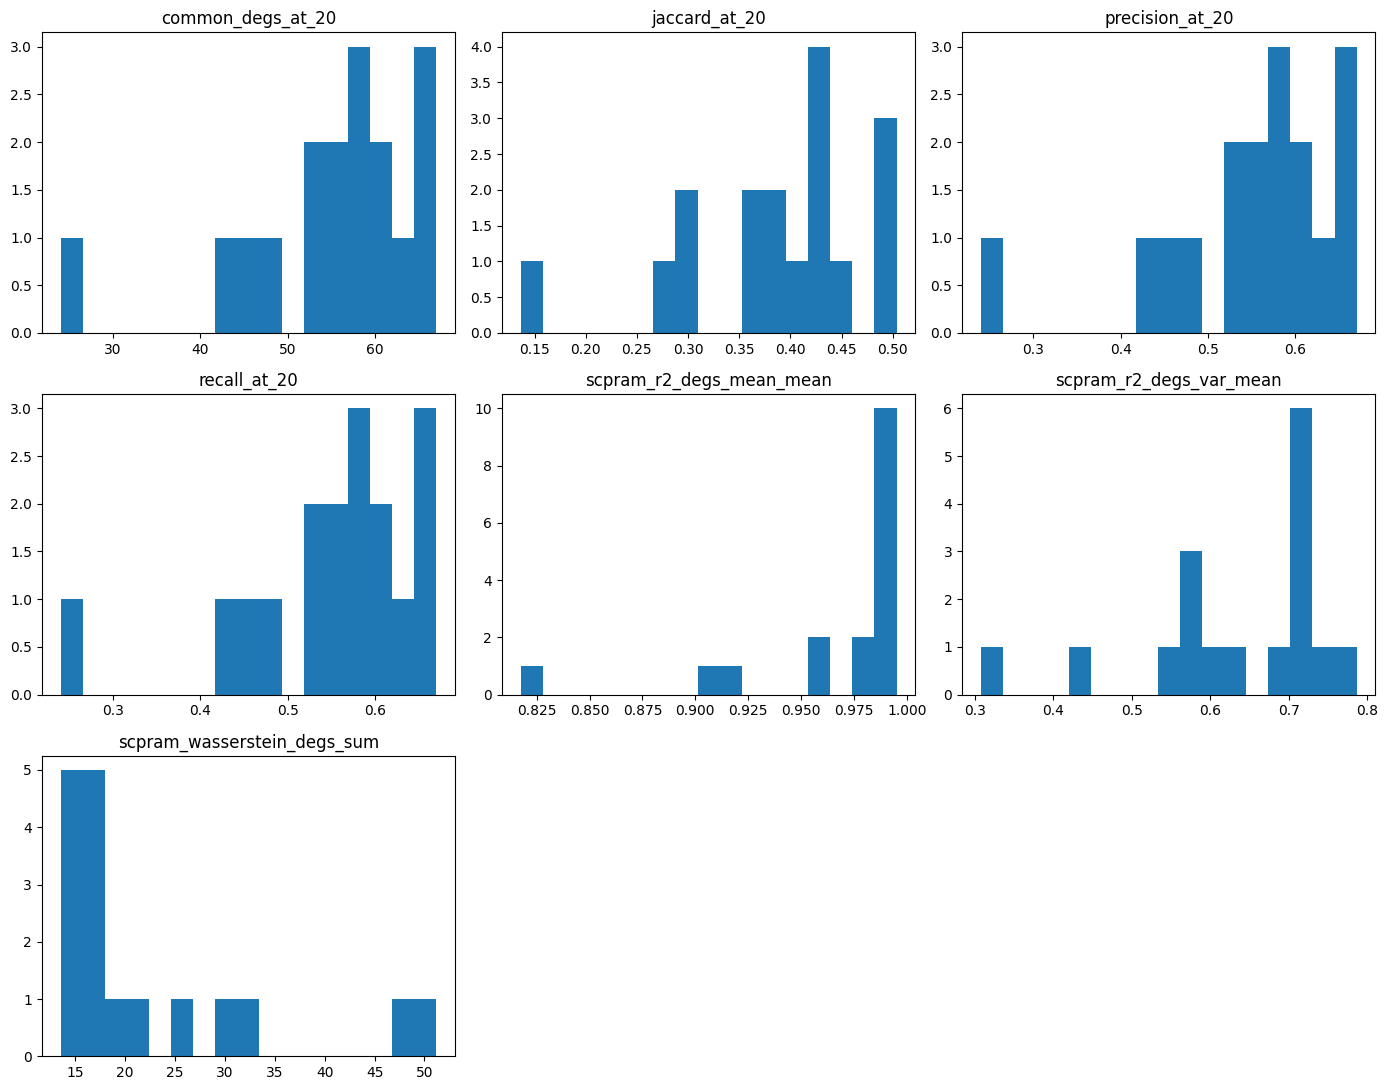

,count,mean,std,min,25%,50%,75%,max
common_degs_at_20,17.0,55.117647,10.629454,24.000000,54.000000,57.000000,61.000000,67.000000
jaccard_at_20,17.0,0.386841,0.093287,0.136364,0.369863,0.398601,0.438849,0.503759
precision_at_20,17.0,0.551176,0.106295,0.240000,0.540000,0.570000,0.610000,0.670000
recall_at_20,17.0,0.551176,0.106295,0.240000,0.540000,0.570000,0.610000,0.670000
scpram_r2_degs_mean_mean,17.0,0.966375,0.046042,0.817369,0.962154,0.985507,0.991548,0.995176
scpram_r2_degs_var_mean,17.0,0.633178,0.122498,0.307958,0.570097,0.679380,0.714093,0.786751
scpram_wasserstein_degs_sum,17.0,22.495983,11.750246,13.515372,15.195048,17.040716,25.842792,51.192151


In [121]:
metric_cols = [
    "common_degs_at_20",
    "jaccard_at_20",
    "precision_at_20",
    "recall_at_20",
    "scpram_r2_degs_mean_mean",
    "scpram_r2_degs_var_mean",
    "scpram_wasserstein_degs_sum",
]
plot_df = result.per_condition_df[metric_cols].apply(pd.to_numeric, errors="coerce")
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.ravel()
for ax, col in zip(axes, metric_cols):
    vals = plot_df[col].dropna()
    ax.hist(vals, bins=min(20, max(5, len(vals))))
    ax.set_title(col)
for ax in axes[len(metric_cols):]:
    ax.axis("off")
fig.tight_layout()
plt.show()

display(result.per_condition_df[metric_cols].describe().T)


## Representative Conditions

默认会自动挑 overlap 最好 / 中位 / 最差的 3 个 condition；如果你在参数里填了 `focus_conditions`，这里就按你指定的 condition 展示。


In [122]:
rep_cols = [
    "split_id",
    "condition",
    "truth_deg_mode_used",
    "pred_deg_mode_used",
    "common_degs_at_20",
    "jaccard_at_20",
    "scpram_r2_degs_mean_mean",
    "scpram_r2_degs_var_mean",
    "scpram_wasserstein_degs_sum",
]
display(result.representative_df[rep_cols])


,split_id,condition,truth_deg_mode_used,pred_deg_mode_used,common_degs_at_20,jaccard_at_20,scpram_r2_degs_mean_mean,scpram_r2_degs_var_mean,scpram_wasserstein_degs_sum
0,1,MANF+ctrl,ttest_non_dropout,effect_size_non_dropout,67,0.503759,0.995176,0.679380,14.120544
1,1,DERL2+ctrl,ttest_non_dropout,effect_size_non_dropout,57,0.398601,0.992902,0.786751,16.632420
2,1,BHLHE40+ctrl,ttest_non_dropout,effect_size_non_dropout,24,0.136364,0.908418,0.558763,51.192151



=== split 1 | MANF+ctrl ===


d:\conda_envs\scouter\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,truth_deg_top100,pred_deg_top100,common_deg_top100
0,RPL28,MAT2A,MAT2A
1,RPS12,RPS29,RPS29
2,RPL37,RPS21,RPS21
3,RPL37A,DDIT4,DDIT4
4,MAT2A,SH3BGRL3,SH3BGRL3
...,...,...,...
95,RP11-85G21.3,HSPA5,NaN
96,RPS3A,RHCE,NaN
97,RPSAP58,RPS8,NaN
98,STIM2,SRSF4,NaN


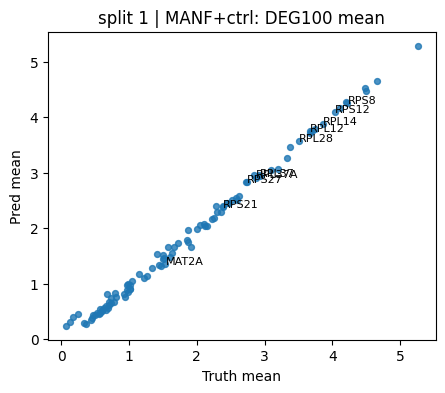

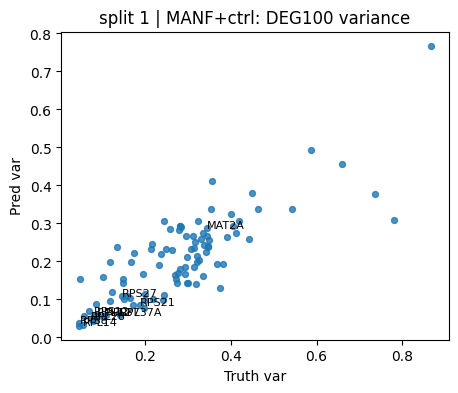


=== split 1 | DERL2+ctrl ===


d:\conda_envs\scouter\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,truth_deg_top100,pred_deg_top100,common_deg_top100
0,RPS21,HBZ,RPS29
1,RPS12,RPS29,SH3BGRL3
2,RPS29,SH3BGRL3,RPS21
3,RPL28,RPS21,HBA1
4,RPL37A,HBA1,RPS28
...,...,...,...
95,CD59,OSBPL8,NaN
96,MDK,PRKDC,NaN
97,CEP350,ACAT2,NaN
98,ZC3H13,BSG,NaN


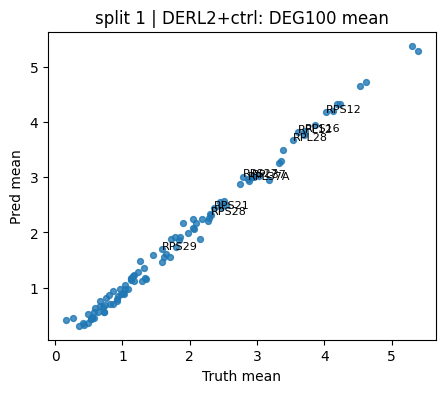

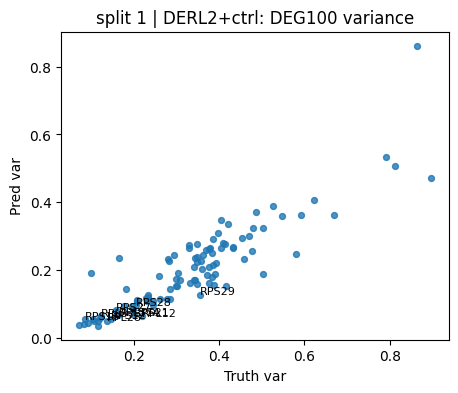


=== split 1 | BHLHE40+ctrl ===


d:\conda_envs\scouter\lib\site-packages\anndata\_core\aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,truth_deg_top100,pred_deg_top100,common_deg_top100
0,SLC25A6,HBZ,HBZ
1,RPS10,SH3BGRL3,MAT2A
2,CD99,RPS29,CYBA
3,RPS27,RPS21,IFITM2
4,CHI3L2,VIM,DDIT4
...,...,...,...
95,PMAIP1,CTSH,NaN
96,RPS24,TMED2,NaN
97,DNAJB9,SSR4,NaN
98,MIR4435-1HG,CANX,NaN


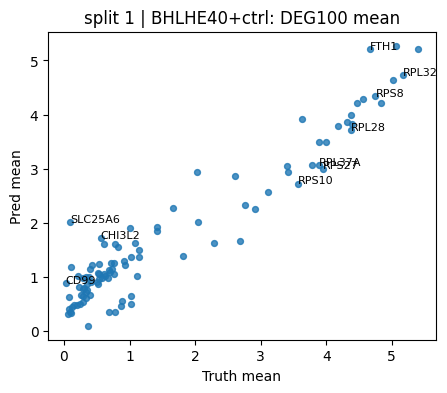

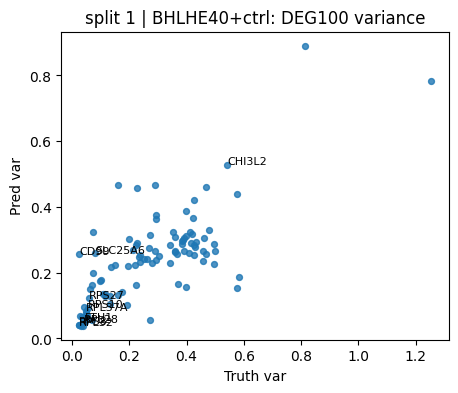

In [123]:
for row in result.representative_df.to_dict(orient="records"):
    split_id = int(row["split_id"])
    condition = str(row["condition"])
    payload_item = load_condition_payload(
        model_name=model_name,
        dataset=dataset,
        split_id=split_id,
        condition=condition,
        result_dir=result_dir,
        variant_tag=variant_tag,
    )
    detail = summarize_condition_payload(
        payload_item=payload_item,
        condition=condition,
        truth_deg_mode=truth_deg_mode,
        pred_deg_mode=pred_deg_mode,
        remove_perturbed_genes=remove_perturbed_genes,
        n_degs=n_degs,
    )
    print(f"\n=== split {split_id} | {condition} ===")
    display(
        pd.DataFrame(
            {
                f"truth_deg_top{n_degs}": pd.Series(detail["truth_deg20"]),
                f"pred_deg_top{n_degs}": pd.Series(detail["pred_deg20"]),
                f"common_deg_top{n_degs}": pd.Series(detail["common_deg20"]),
            }
        )
    )
    fig_mean, fig_var = build_mean_var_scatter(
        payload_item=payload_item,
        truth_deg_idx=detail["truth_deg_idx"],
        title_prefix=f"split {split_id} | {condition}",
        n_degs=n_degs,
    )
    plt.show(fig_mean)
    plt.show(fig_var)
    plt.close(fig_mean)
    plt.close(fig_var)


## Exported Gene Lists

主流程默认总会导出三类 gene list：`truth_deg20` / `pred_deg20` / `common_deg20`。


In [124]:
display(result.gene_lists_df.head(30))
print(result.out_dir / "deg_gene_lists_long.csv")


,model_name,dataset,split_id,condition,focus_key,list_type,rank,gene,deg_top_k,truth_deg_mode_used,pred_deg_mode_used
0,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,1,HBZ,100,ttest_non_dropout,effect_size_non_dropout
1,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,2,RPS29,100,ttest_non_dropout,effect_size_non_dropout
2,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,3,SH3BGRL3,100,ttest_non_dropout,effect_size_non_dropout
3,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,4,HBA1,100,ttest_non_dropout,effect_size_non_dropout
4,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,5,RPS21,100,ttest_non_dropout,effect_size_non_dropout
5,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,6,RPS28,100,ttest_non_dropout,effect_size_non_dropout
6,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,7,DDIT4,100,ttest_non_dropout,effect_size_non_dropout
7,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,8,RPL37A,100,ttest_non_dropout,effect_size_non_dropout
8,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,9,MDK,100,ttest_non_dropout,effect_size_non_dropout
9,trishift,adamson,1,ATP5B+ctrl,1:ATP5B+ctrl,common_deg20,10,IFITM2,100,ttest_non_dropout,effect_size_non_dropout


E:\CODE\trishift\artifacts\results\adamson\deg20_downstream_20260315_215005\deg_gene_lists_long.csv


## Optional Enrichment

当 `enrichment_mode="run_if_available"` 且环境里有 `gseapy` 时，这里会显示 enrichment 结果；否则 notebook 只保留 gene list 导出。


In [125]:
if result.enrichment_df.empty:
    print("No enrichment results. This is expected when enrichment_mode='export_only' or gseapy is unavailable.")
else:
    display(result.enrichment_df.head(30))


No enrichment results. This is expected when enrichment_mode='export_only' or gseapy is unavailable.


## Notes

- `common_degs_at_20` 和 `jaccard_at_20` 更直接回答“预测 DEG20 和 truth DEG20 重合多少”。
- `scpram_r2_degs_mean_mean` / `scpram_r2_degs_var_mean` 更接近 scPRAM 论文里 DEG mean/variance regression 的思想。
- `scpram_wasserstein_degs_sum` 越低越好，表示预测和真实在 DEG20 子空间上的分布差更小。
